In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

In [11]:
df = pd.read_csv("../data/zinc250k.csv")
df['smiles'] = df['smiles'].str.strip()
df.head()

,Unnamed: 0,index,smiles,selfies,logP,qed,SAS
0,0,0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1,[C][C][Branch1][C][C][Branch1][C][C][C][=C][C]...,5.05060,0.702012,2.084095
1,1,1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1,[C][C@@H1][C][C][Branch2][Ring1][Ring2][N][C][...,3.11370,0.928975,3.432004
2,2,2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,[N][#C][C][=C][C][=C][Branch2][Ring2][Ring2][C...,4.96778,0.599682,2.470633
3,3,3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,[C][C][O][C][=Branch1][C][=O][C@@H1][C][C][C][...,4.00022,0.690944,2.822753
4,4,4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,[N][#C][C][=C][Branch2][Ring1][Ring1][S][C][C]...,3.60956,0.789027,4.035182


In [12]:
print(len(df))

249455


In [13]:
df.isna().sum()

Unnamed: 0    0
index         0
smiles        0
selfies       0
logP          0
qed           0
SAS           0
dtype: int64

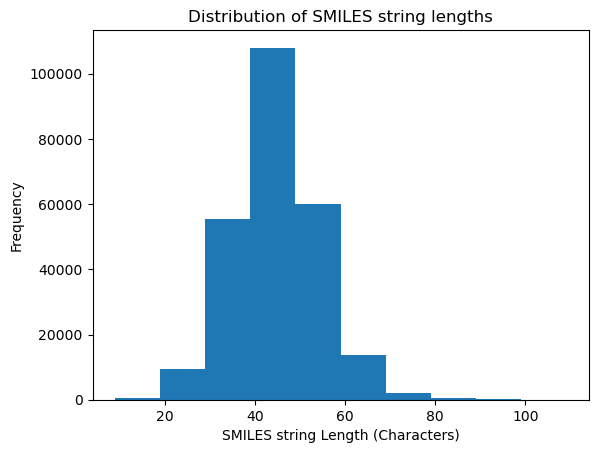

In [14]:
df["smiles"].str.len().plot(kind="hist", title="Distribution of SMILES string lengths")

plt.xlabel("SMILES string Length (Characters)")
plt.ylabel("Frequency")
plt.show()

Checking the amount of characters in SMILES strings shows the amount of tokens each string will have if we employ character tokenization

We used this information to select 68 as our max sequence length for character tokenization, because it covers 99% of strings in the dataset

In [16]:
print(df["smiles"].str.len().max())
print(df['smiles'].str.len().quantile(0.99))
print(df['smiles'].str.len().quantile(0.95))
print(df['smiles'].str.len().quantile(0.90))

109
68.0
60.0
56.0


This code applies atom_tokenization to the smiles strings, so we can look at the distribution of the amount of tokens per string.

We used this information to select 59 as our max sequence length for atom tokenization, because it covers 99% of strings in the dataset

In [20]:
import sys
from pathlib import Path

def find_project_root(marker=".git") -> Path:
    path = Path.cwd()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root (no {marker} found)")

project_root = find_project_root()
sys.path.append(str(project_root))

from src.tokenizer import atom_tokenize
import numpy as np

token_counts = [len(atom_tokenize(smiles)) for smiles in df['smiles']]

print(max(token_counts))
print(np.quantile(token_counts, 0.99))
print(np.quantile(token_counts, 0.95))
print(np.quantile(token_counts, 0.9))

72
59.0
53.0
49.0


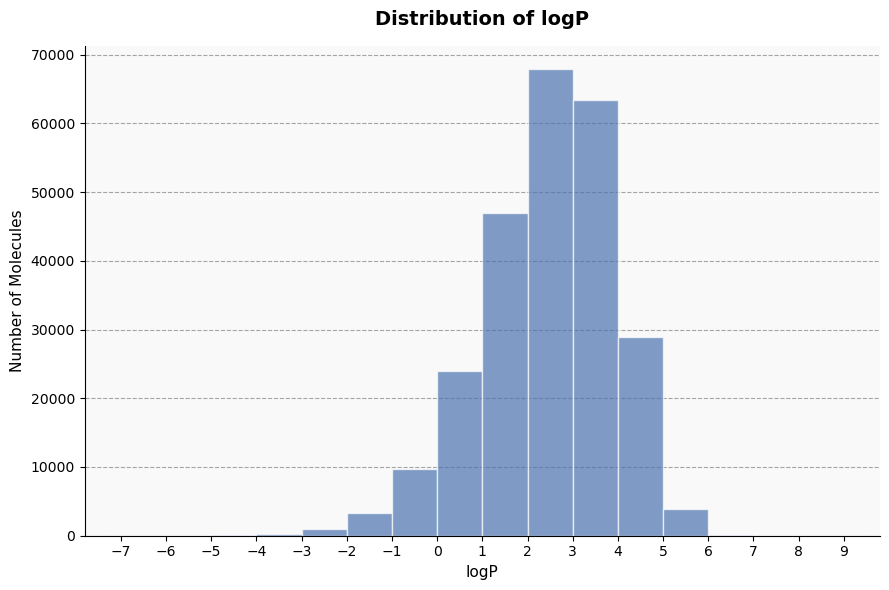

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

logp_min = np.floor(df["logP"].min() )
logp_max = np.ceil(df["logP"].max())
bins = np.arange(logp_min, logp_max + 1, 1)

ax.hist(df["logP"], bins=bins, color='#4C72B0', alpha=0.7, edgecolor='white')

# Labels and title
ax.set_title('Distribution of logP (Octanol-Water Partition Coefficient)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('logP', fontsize=11)
ax.set_ylabel('Number of Molecules', fontsize=11)



# More x tick labels
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# Grid and styling
ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)
ax.set_facecolor('#F9F9F9')
fig.patch.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

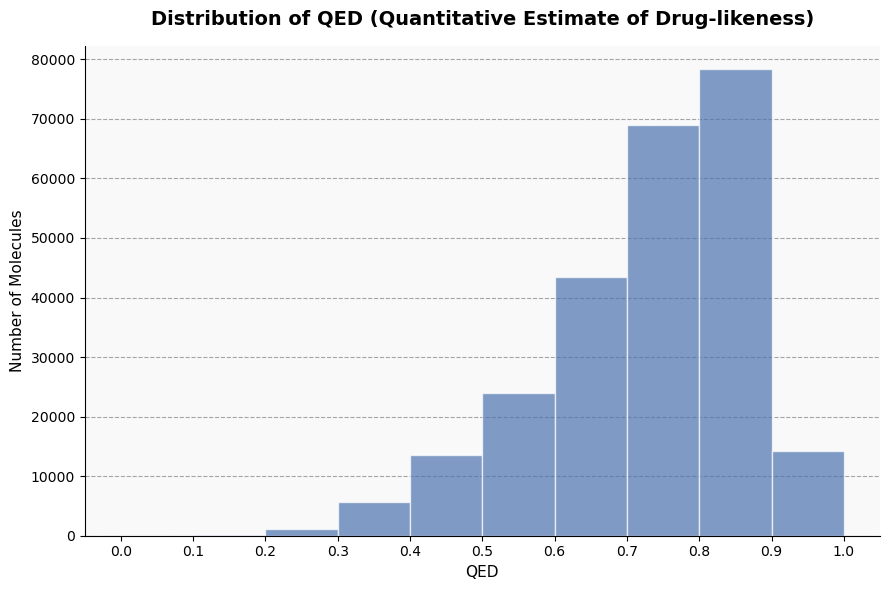

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))

bins = np.arange(0, 1.1, .1)

ax.hist(df["qed"], bins=bins, color='#4C72B0', alpha=0.7, edgecolor='white')

# Labels and title
ax.set_title('Distribution of QED (Quantitative Estimate of Drug-likeness)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('QED', fontsize=11)
ax.set_ylabel('Number of Molecules', fontsize=11)



# More x tick labels
ax.xaxis.set_major_locator(mticker.MultipleLocator(.1))

# Grid and styling
ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)
ax.set_facecolor('#F9F9F9')
fig.patch.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

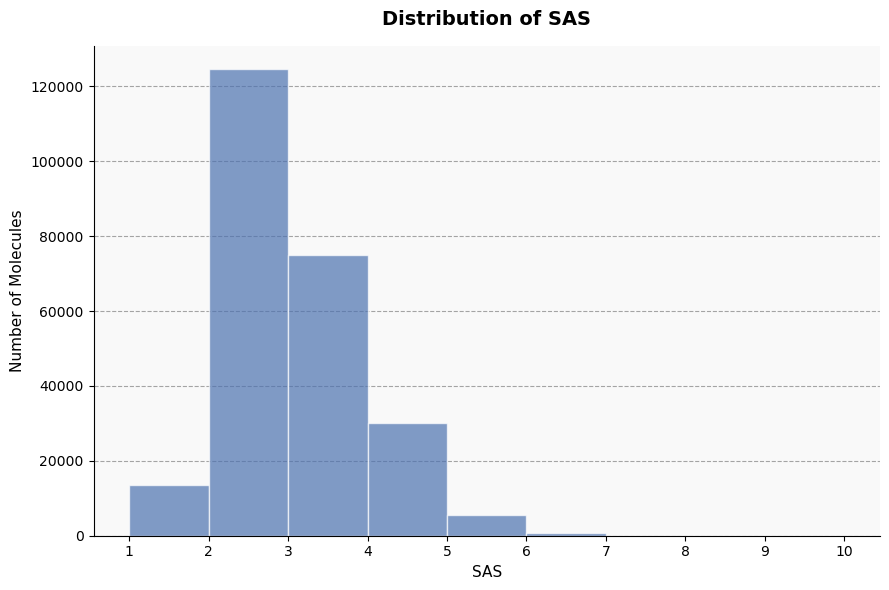

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))

bins = np.arange(1, 11, 1)

ax.hist(df["SAS"], bins=bins, color='#4C72B0', alpha=0.7, edgecolor='white')

# Labels and title
ax.set_title('Distribution of SAS', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('SAS', fontsize=11)
ax.set_ylabel('Number of Molecules', fontsize=11)



# More x tick labels
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

# Grid and styling
ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)
ax.set_facecolor('#F9F9F9')
fig.patch.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()